In [3]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv('placement.csv')

In [7]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [9]:
df.shape

(100, 4)

# Steps
# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [10]:
df=df.iloc[:,1:] 

In [11]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [12]:
import matplotlib.pyplot as plt

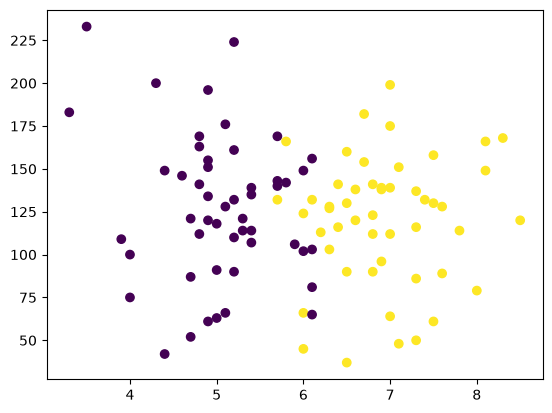

In [17]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

# we use logistic regrssion

In [19]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [22]:
x.head()


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [23]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [28]:
x_train


,cgpa,iq
92,5.2,110.0
72,7.3,116.0
45,6.0,66.0
21,7.1,151.0
31,3.9,109.0
...,...,...
25,5.0,91.0
77,7.3,50.0
33,6.0,149.0
65,8.1,166.0


In [29]:
y_train

92    0
72    1
45    1
21    1
31    0
     ..
25    0
77    1
33    0
65    1
60    1
Name: placement, Length: 90, dtype: int64

In [30]:
x_test

,cgpa,iq
76,4.9,155.0
3,7.4,132.0
24,4.7,121.0
73,4.9,61.0
86,5.1,128.0
56,6.1,65.0
57,6.5,130.0
14,6.1,103.0
35,6.8,90.0
43,6.8,141.0


In [31]:
y_test

76    0
3     1
24    0
73    0
86    0
56    0
57    1
14    0
35    1
43    1
Name: placement, dtype: int64

In [35]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [37]:
x_train


array([[-6.87865696e-01, -3.65588276e-01],
       [ 1.12281142e+00, -2.17376813e-01],
       [ 1.91606044e-03, -1.45247234e+00],
       [ 9.50365976e-01,  6.47190056e-01],
       [-1.80876105e+00, -3.90290186e-01],
       [ 1.74361500e-01, -2.91482544e-01],
       [ 1.91606044e-03, -1.97121246e+00],
       [ 1.55392501e+00, -2.66780634e-01],
       [-2.56752098e-01,  3.75469040e-01],
       [ 8.81387801e-02,  7.70699609e-01],
       [-2.56752098e-01,  1.77853756e-01],
       [ 4.33029659e-01, -8.59626487e-01],
       [ 5.19252378e-01, -1.18569171e-01],
       [-2.56752098e-01,  1.09182445e+00],
       [-6.01642977e-01, -2.66780634e-01],
       [-1.70529379e-01,  4.24872861e-01],
       [-1.03275657e+00,  9.43612983e-01],
       [-7.74088416e-01,  1.26473782e+00],
       [-2.32609737e+00,  1.43765119e+00],
       [ 2.60584219e-01, -5.38501650e-01],
       [-6.01642977e-01, -9.38672600e-02],
       [ 1.81259317e+00,  5.97786235e-01],
       [ 7.77920537e-01, -7.11415023e-01],
       [-8.

In [38]:
x_test=scaler.transform(x_test)

In [39]:
x_test

array([[-0.94653386,  0.7459977 ],
       [ 1.20903414,  0.17785376],
       [-1.11897929, -0.09386726],
       [-0.94653386, -1.57598189],
       [-0.77408842,  0.07904611],
       [ 0.08813878, -1.47717425],
       [ 0.43302966,  0.12844993],
       [ 0.08813878, -0.53850165],
       [ 0.69169782, -0.85962649],
       [ 0.69169782,  0.40017095]])

In [40]:
from sklearn.linear_model import LogisticRegression


In [41]:
clf=LogisticRegression()

In [42]:
#model training step

In [43]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [55]:
y_predict=clf.predict(x_test)

In [45]:
y_test

76    0
3     1
24    0
73    0
86    0
56    0
57    1
14    0
35    1
43    1
Name: placement, dtype: int64

In [64]:
from sklearn.metrics import accuracy_score

In [63]:
accuracy_score(y_test,y_predict)

1.0

In [58]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

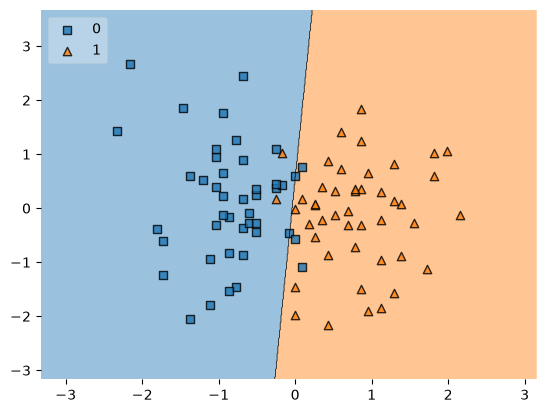

In [59]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [60]:
import pickle

In [61]:
pickle.dump(clf,open('model.pkl','wb'))